In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the pre-trained Haar cascade classifiers
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# Check if cascades loaded successfully
if face_cascade.empty():
    print("Error: Could not load face cascade classifier.")
if smile_cascade.empty():
    print("Error: Could not load smile cascade classifier.")

Next, let's load an image. You can upload your own image or use a sample one. For demonstration, I'll download a sample image. After running this cell, you can replace the image path with your own if needed.

Image loaded successfully.


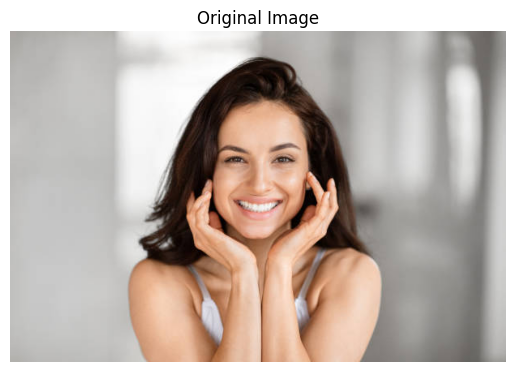

In [2]:
import requests
import os

# Define the filename for the user's image
image_filename = 'smile detection.jpg'

# Assuming the image is already uploaded to the Colab environment
# We will skip the download logic as the file should be available locally.

# Load the image
image_path = image_filename
img = cv2.imread(image_path)

# Check if image loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}. Please ensure the file is uploaded to the Colab environment.")
else:
    print("Image loaded successfully.")

# Convert image to grayscale (required for cascade classifiers)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display the original image (optional, for verification)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

Now, let's detect faces in the image. Once faces are detected, we will iterate through each detected face and look for smiles within those facial regions.

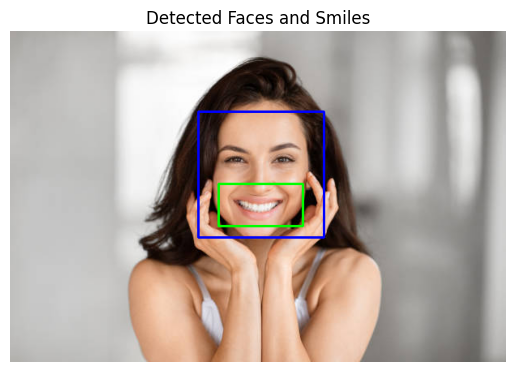

In [3]:
# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5,
    minSize=(30, 30)
)

# Draw rectangles around faces and detect smiles within them
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle for face

    # Region of Interest for the face in grayscale and color
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # Detect smiles in the face region
    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25)
    )

    # Draw rectangles around smiles
    for (sx, sy, sw, sh) in smiles:
        # Ensure smile is detected in the lower half of the face to avoid false positives
        if sy > h * 0.4: # Check if smile is below 40% of face height
            cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 2) # Green rectangle for smile

# Display the output image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Detected Faces and Smiles')
plt.axis('off')
plt.show()